In [25]:
import sqlite3
import pandas as pd
import numpy as np

In [26]:
conn = sqlite3.connect("../database/hospital.db")

In [27]:
query = """
WITH diagnosis_summary AS (

    SELECT
        admission_id,

        -- Primary Diagnosis
        MAX(CASE
                WHEN diag_rank = 1
                THEN diag_desc
            END) AS primary_diagnosis,

        -- Primary Diagnosis Category
        MAX(CASE
                WHEN diag_rank = 1
                THEN diag_category
            END) AS primary_diag_category,

        -- Primary ICD-10 Code
        MAX(CASE
                WHEN diag_rank = 1
                THEN icd10_code
            END) AS primary_icd10,

        -- Total number of diagnoses
        COUNT(*) AS total_diagnoses,

        -- All diagnosis descriptions
        GROUP_CONCAT(diag_desc, ', ') AS diagnosis_list,

        -- All diagnosis categories
        GROUP_CONCAT(DISTINCT diag_category) AS diagnosis_categories

    FROM diagnoses

    GROUP BY admission_id
)

SELECT

    --------------------------------------------------------
    -- Admission Information
    --------------------------------------------------------

    a.admission_id,
    a.patient_id,
    a.hospital_id,
    a.admit_date,
    a.discharge_date,
    a.admit_type,
    a.ward_type,
    a.los_days,
    a.readmitted_30d,

    --------------------------------------------------------
    -- Patient Information
    --------------------------------------------------------

    p.age,
    p.gender,
    p.state AS patient_state,
    p.insurance_type,

    --------------------------------------------------------
    -- Hospital Information
    --------------------------------------------------------

    h.name AS hospital_name,
    h.state AS hospital_state,
    h.tier AS hospital_tier,
    h.beds,
    h.teaching,

    --------------------------------------------------------
    -- Diagnosis Features
    --------------------------------------------------------

    ds.primary_icd10,
    ds.primary_diagnosis,
    ds.primary_diag_category,
    ds.total_diagnoses,
    ds.diagnosis_list,
    ds.diagnosis_categories,

    --------------------------------------------------------
    -- Billing Information
    --------------------------------------------------------

    b.cost_category,
    b.total_cost_inr

FROM admissions a

INNER JOIN patients p
    ON a.patient_id = p.patient_id

INNER JOIN hospitals h
    ON a.hospital_id = h.hospital_id

INNER JOIN billing b
    ON a.admission_id = b.admission_id

INNER JOIN diagnosis_summary ds
    ON a.admission_id = ds.admission_id
"""

In [28]:
df = pd.read_sql(query, conn)

In [29]:
df.head()

,admission_id,patient_id,hospital_id,admit_date,discharge_date,admit_type,ward_type,los_days,readmitted_30d,age,...,beds,teaching,primary_icd10,primary_diagnosis,primary_diag_category,total_diagnoses,diagnosis_list,diagnosis_categories,cost_category,total_cost_inr
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,2024-01-23,2024-01-27,Elective,General,4,0,46,...,359,1,E87,Metabolic / electrolyte disorder,Endocrine,1,Metabolic / electrolyte disorder,Endocrine,Lab,18492
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,8b1e01b7-9f0e-413f-b330-454d271a5c6e,2019-11-18,2019-11-19,OPD,General,1,0,31,...,67,0,J45,Asthma,Respiratory,1,Asthma,Respiratory,Lab,1001
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,2019-11-22,2019-11-27,Emergency,General,5,1,53,...,1018,1,G40,Epilepsy,Neurological,3,"Epilepsy, Pulmonary tuberculosis, Atrial fibri...","Neurological,Infectious,Cardiovascular",Room,59696
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,df4431ea-1acf-4e77-963c-6173e9787151,2020-03-05,2020-03-16,Emergency,ICU,11,1,56,...,191,0,I50,Heart failure,Cardiovascular,1,Heart failure,Cardiovascular,Lab,72588
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,8b1e01b7-9f0e-413f-b330-454d271a5c6e,2018-05-30,2018-06-04,Emergency,General,5,1,69,...,67,0,C50,Malignant neoplasm — breast,Neoplasm,3,"Malignant neoplasm — breast, COPD, Alcoholic l...","Neoplasm,Respiratory,Gastrointestinal",Lab,9510


In [30]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 120000
Columns : 26


In [31]:
df.columns

Index(['admission_id', 'patient_id', 'hospital_id', 'admit_date',
       'discharge_date', 'admit_type', 'ward_type', 'los_days',
       'readmitted_30d', 'age', 'gender', 'patient_state', 'insurance_type',
       'hospital_name', 'hospital_state', 'hospital_tier', 'beds', 'teaching',
       'primary_icd10', 'primary_diagnosis', 'primary_diag_category',
       'total_diagnoses', 'diagnosis_list', 'diagnosis_categories',
       'cost_category', 'total_cost_inr'],
      dtype='str')

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   admission_id           120000 non-null  str  
 1   patient_id             120000 non-null  str  
 2   hospital_id            120000 non-null  str  
 3   admit_date             120000 non-null  str  
 4   discharge_date         120000 non-null  str  
 5   admit_type             120000 non-null  str  
 6   ward_type              120000 non-null  str  
 7   los_days               120000 non-null  int64
 8   readmitted_30d         120000 non-null  int64
 9   age                    120000 non-null  int64
 10  gender                 120000 non-null  str  
 11  patient_state          120000 non-null  str  
 12  insurance_type         86013 non-null   str  
 13  hospital_name          120000 non-null  str  
 14  hospital_state         120000 non-null  str  
 15  hospital_tier          12000

In [33]:
df.describe(include='all')

,admission_id,patient_id,hospital_id,admit_date,discharge_date,admit_type,ward_type,los_days,readmitted_30d,age,...,beds,teaching,primary_icd10,primary_diagnosis,primary_diag_category,total_diagnoses,diagnosis_list,diagnosis_categories,cost_category,total_cost_inr
count,120000,120000,120000,120000,120000,120000,120000,120000.000000,120000.000000,120000.000000,...,120000.000000,120000.000000,120000,120000,120000,120000.000000,120000,120000,120000,1.200000e+05
unique,120000,64873,33,3652,3677,3,4,NaN,NaN,NaN,...,NaN,NaN,34,34,11,NaN,42016,6453,4,NaN
top,bcb311d6-0808-498f-8ae1-11abe1fbc08e,dd0ca7f5-a2e4-4077-8602-49690edaca7e,a86650ea-3517-4285-bc11-ffa2085a8df2,2019-07-06,2020-07-01,Emergency,General,NaN,NaN,NaN,...,NaN,NaN,E10,Type 1 diabetes mellitus,Cardiovascular,NaN,Type 1 diabetes mellitus,Cardiovascular,Pharmacy,NaN
freq,1,10,3736,56,56,66540,76768,NaN,NaN,NaN,...,NaN,NaN,5813,5813,23964,NaN,1994,7744,36280,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.852708,0.118417,48.049867,...,439.808733,0.575725,NaN,NaN,NaN,2.261175,NaN,NaN,NaN,9.577953e+04
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.708269,0.323102,21.635289,...,289.486944,0.494235,NaN,NaN,NaN,1.157536,NaN,NaN,NaN,1.955118e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,...,61.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,6.490000e+02
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.000000,36.000000,...,191.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,1.202300e+04
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,0.000000,51.000000,...,423.000000,1.000000,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,3.097050e+04
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,0.000000,63.000000,...,632.000000,1.000000,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,8.940700e+04


In [34]:
df.isnull().sum()

admission_id                 0
patient_id                   0
hospital_id                  0
admit_date                   0
discharge_date               0
admit_type                   0
ward_type                    0
los_days                     0
readmitted_30d               0
age                          0
gender                       0
patient_state                0
insurance_type           33987
hospital_name                0
hospital_state               0
hospital_tier                0
beds                         0
teaching                     0
primary_icd10                0
primary_diagnosis            0
primary_diag_category        0
total_diagnoses              0
diagnosis_list               0
diagnosis_categories         0
cost_category                0
total_cost_inr               0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df["admission_id"].duplicated().sum()

np.int64(0)

In [37]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)
print("\n")


df["admit_date"] = pd.to_datetime(df["admit_date"])
df["discharge_date"] = pd.to_datetime(df["discharge_date"])

print("Updated Data Types:\n")
print(df.dtypes)

print("\n")
print(df.info())

DATA TYPES
admission_id               str
patient_id                 str
hospital_id                str
admit_date                 str
discharge_date             str
admit_type                 str
ward_type                  str
los_days                 int64
readmitted_30d           int64
age                      int64
gender                     str
patient_state              str
insurance_type             str
hospital_name              str
hospital_state             str
hospital_tier              str
beds                     int64
teaching                 int64
primary_icd10              str
primary_diagnosis          str
primary_diag_category      str
total_diagnoses          int64
diagnosis_list             str
diagnosis_categories       str
cost_category              str
total_cost_inr           int64
dtype: object


Updated Data Types:

admission_id                        str
patient_id                          str
hospital_id                         str
admit_date               d

In [38]:
print("=" * 60)
print("DATE FEATURE ENGINEERING")
print("=" * 60)


df["admit_year"] = df["admit_date"].dt.year
df["admit_month"] = df["admit_date"].dt.month
df["admit_day"] = df["admit_date"].dt.day
df["admit_weekday"] = df["admit_date"].dt.day_name()
df["admit_quarter"] = df["admit_date"].dt.quarter
df["discharge_year"] = df["discharge_date"].dt.year
df["discharge_month"] = df["discharge_date"].dt.month

df["calculated_los"] = (
    df["discharge_date"] - df["admit_date"]
).dt.days

print("Checking LOS consistency...\n")

los_check = (
    df["calculated_los"] == df["los_days"]
).value_counts()

print(los_check)

print("\nSample Date Features\n")

display(
    df[
        [
            "admit_date",
            "discharge_date",
            "admit_year",
            "admit_month",
            "admit_weekday",
            "admit_quarter",
            "los_days",
            "calculated_los"
        ]
    ].head()
)

DATE FEATURE ENGINEERING
Checking LOS consistency...

True    120000
Name: count, dtype: int64

Sample Date Features



,admit_date,discharge_date,admit_year,admit_month,admit_weekday,admit_quarter,los_days,calculated_los
0,2024-01-23,2024-01-27,2024,1,Tuesday,1,4,4
1,2019-11-18,2019-11-19,2019,11,Monday,4,1,1
2,2019-11-22,2019-11-27,2019,11,Friday,4,5,5
3,2020-03-05,2020-03-16,2020,3,Thursday,1,11,11
4,2018-05-30,2018-06-04,2018,5,Wednesday,2,5,5


OUTLIER ANALYSIS


age
count    120000.000000
mean         48.049867
std          21.635289
min           0.000000
25%          36.000000
50%          51.000000
75%          63.000000
max          95.000000
Name: age, dtype: float64

Lower Bound : -4.50
Upper Bound : 103.50
Outliers    : 0


C:\Users\gurle\AppData\Local\Temp\ipykernel_11532\452175423.py:46: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


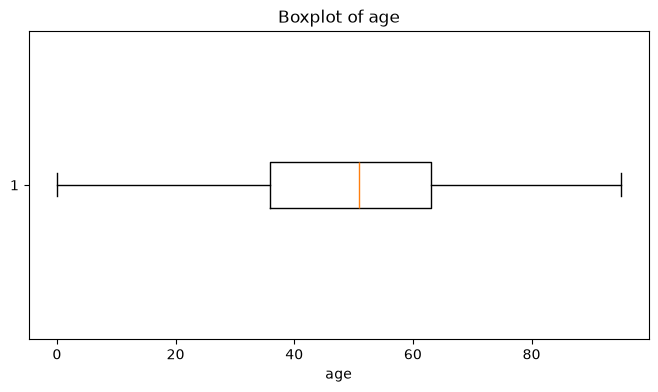



los_days
count    120000.000000
mean          6.852708
std           5.708269
min           1.000000
25%           3.000000
50%           5.000000
75%           9.000000
max          90.000000
Name: los_days, dtype: float64

Lower Bound : -6.00
Upper Bound : 18.00
Outliers    : 5812


C:\Users\gurle\AppData\Local\Temp\ipykernel_11532\452175423.py:46: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


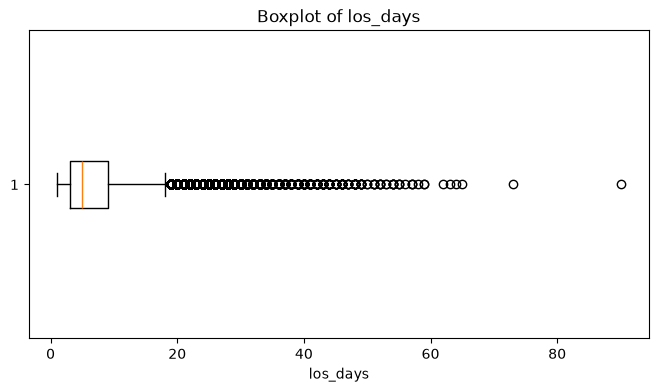



beds
count    120000.000000
mean        439.808733
std         289.486944
min          61.000000
25%         191.000000
50%         423.000000
75%         632.000000
max        1018.000000
Name: beds, dtype: float64

Lower Bound : -470.50
Upper Bound : 1293.50
Outliers    : 0


C:\Users\gurle\AppData\Local\Temp\ipykernel_11532\452175423.py:46: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


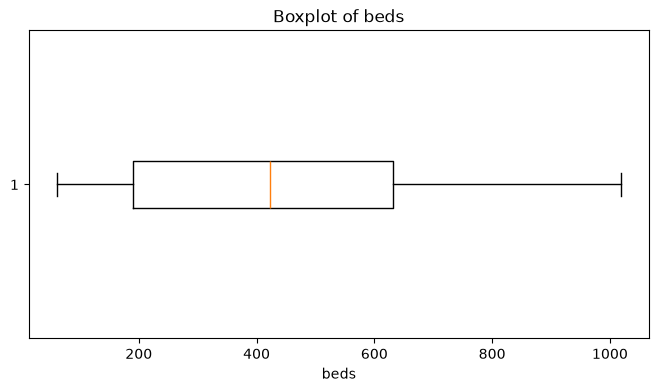



total_diagnoses
count    120000.000000
mean          2.261175
std           1.157536
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           4.000000
Name: total_diagnoses, dtype: float64

Lower Bound : -2.00
Upper Bound : 6.00
Outliers    : 0


C:\Users\gurle\AppData\Local\Temp\ipykernel_11532\452175423.py:46: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


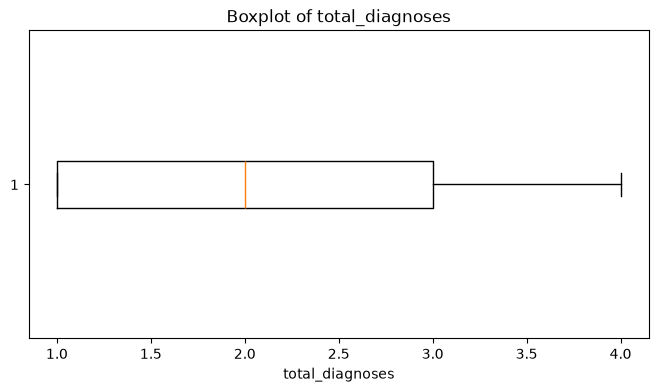



total_cost_inr
count    1.200000e+05
mean     9.577953e+04
std      1.955118e+05
min      6.490000e+02
25%      1.202300e+04
50%      3.097050e+04
75%      8.940700e+04
max      6.674008e+06
Name: total_cost_inr, dtype: float64

Lower Bound : -104053.00
Upper Bound : 205483.00
Outliers    : 14011


C:\Users\gurle\AppData\Local\Temp\ipykernel_11532\452175423.py:46: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


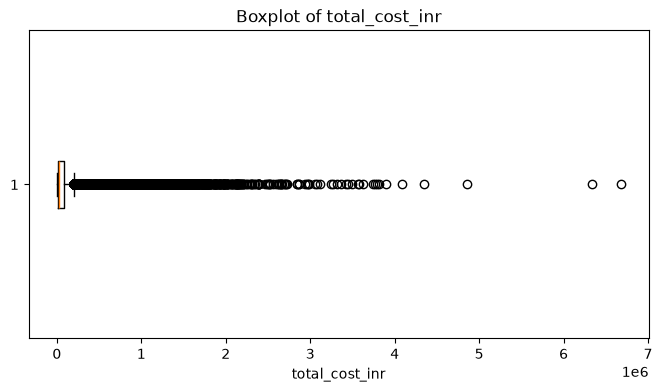

In [39]:
import matplotlib.pyplot as plt

print("=" * 60)
print("OUTLIER ANALYSIS")
print("=" * 60)

numeric_columns = [
    "age",
    "los_days",
    "beds",
    "total_diagnoses",
    "total_cost_inr"
]

for col in numeric_columns:

    print("\n")
    print("=" * 50)
    print(f"{col}")
    print("=" * 50)

    print(df[col].describe())

    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"\nLower Bound : {lower:.2f}")
    print(f"Upper Bound : {upper:.2f}")
    print(f"Outliers    : {len(outliers)}")



    plt.figure(figsize=(8,4))

    plt.boxplot(df[col], vert=False)

    plt.title(f"Boxplot of {col}")

    plt.xlabel(col)

    plt.show()

In [40]:

df.drop(columns=["calculated_los"], inplace=True)

print("Temporary verification column removed.")

Temporary verification column removed.


In [ ]:
df.to_csv(
    "../data/processed/processed_hospital_data.csv",
    index=False
)

print("Processed dataset saved successfully.")


Processed dataset saved successfully.
